In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv("../backend/datasets/water_consumption.csv")

df.head()

,Date,Time,Consumption,Temperature,Rain,Sun
0,1/1/2016,00:00-01:00,1480,0.6,0.0,0
1,1/1/2016,01:00-02:00,1362,0.6,0.0,0
2,1/1/2016,02:00-03:00,1296,0.5,0.0,0
3,1/1/2016,03:00-04:00,1096,0.0,0.0,0
4,1/1/2016,04:00-05:00,810,0.3,0.0,0


In [13]:
df.shape


(46031, 6)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46031 entries, 0 to 46030
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         46031 non-null  object 
 1   Time         46031 non-null  object 
 2   Consumption  46031 non-null  int64  
 3   Temperature  46031 non-null  float64
 4   Rain         46006 non-null  float64
 5   Sun          46031 non-null  int64  
dtypes: float64(2), int64(2), object(2)
memory usage: 2.1+ MB


In [23]:
df.describe()


,Consumption,Temperature,Rain,Sun
count,46031.000000,46031.000000,46031.000000,46031.000000
mean,2314.389281,10.800560,0.050053,1.677370
std,1032.101285,7.763241,0.375570,2.883688
min,1.000000,-17.600000,0.000000,0.000000
25%,1461.500000,5.000000,0.000000,0.000000
50%,2550.000000,10.100000,0.000000,0.000000
75%,3082.000000,16.200000,0.000000,2.000000
max,6514.000000,40.300000,22.000000,20.000000


In [17]:
df.isnull().sum()


Date            0
Time            0
Consumption     0
Temperature     0
Rain           25
Sun             0
dtype: int64

In [19]:
df["Rain"] = df["Rain"].fillna(df["Rain"].median())

In [21]:
df.isnull().sum()

Date           0
Time           0
Consumption    0
Temperature    0
Rain           0
Sun            0
dtype: int64

In [25]:
df["Time"].head()

0     00:00-01:00 
1     01:00-02:00 
2     02:00-03:00 
3     03:00-04:00 
4     04:00-05:00 
Name: Time, dtype: object

In [31]:
df["StartTime"] = df["Time"].str.split("-").str[0]

df["Datetime"] = pd.to_datetime(
    df["Date"] + " " + df["StartTime"],
    format="%m/%d/%Y %H:%M"
)

In [29]:
df[["Date", "Time", "Datetime"]].head()

,Date,Time,Datetime
0,1/1/2016,00:00-01:00,2016-01-01 00:00:00
1,1/1/2016,01:00-02:00,2016-01-01 01:00:00
2,1/1/2016,02:00-03:00,2016-01-01 02:00:00
3,1/1/2016,03:00-04:00,2016-01-01 03:00:00
4,1/1/2016,04:00-05:00,2016-01-01 04:00:00


In [35]:
df["Hour"] = df["Datetime"].dt.hour
df["Day"] = df["Datetime"].dt.day
df["Month"] = df["Datetime"].dt.month
df["DayOfWeek"] = df["Datetime"].dt.dayofweek
df["IsWeekend"] = (df["DayOfWeek"] >= 5).astype(int)

In [37]:
df.head()

,Date,Time,Consumption,Temperature,Rain,Sun,StartTime,Datetime,Hour,Day,Month,DayOfWeek,IsWeekend
0,1/1/2016,00:00-01:00,1480,0.6,0.0,0,00:00,2016-01-01 00:00:00,0,1,1,4,0
1,1/1/2016,01:00-02:00,1362,0.6,0.0,0,01:00,2016-01-01 01:00:00,1,1,1,4,0
2,1/1/2016,02:00-03:00,1296,0.5,0.0,0,02:00,2016-01-01 02:00:00,2,1,1,4,0
3,1/1/2016,03:00-04:00,1096,0.0,0.0,0,03:00,2016-01-01 03:00:00,3,1,1,4,0
4,1/1/2016,04:00-05:00,810,0.3,0.0,0,04:00,2016-01-01 04:00:00,4,1,1,4,0


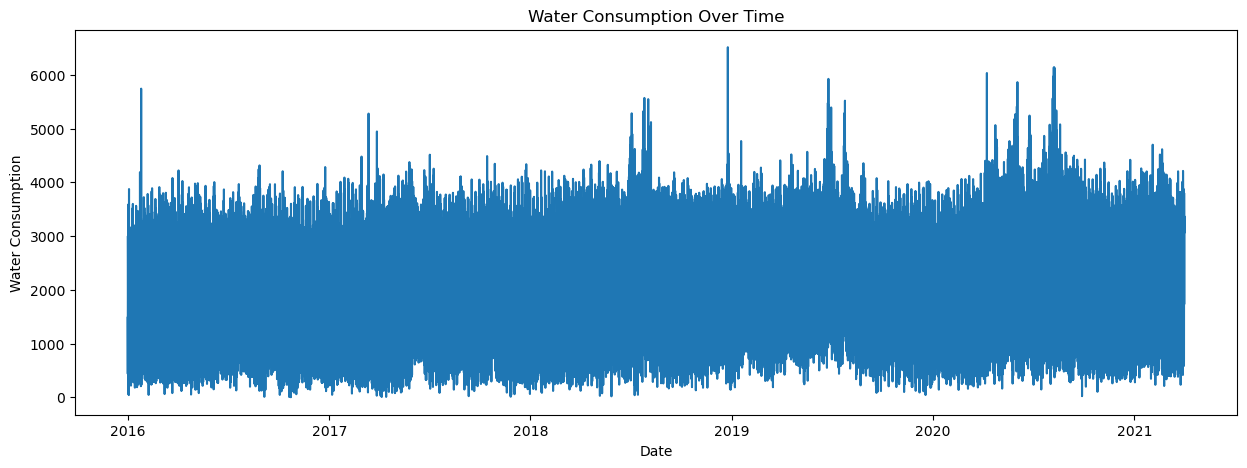

In [41]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 5))

plt.plot(
    df["Datetime"],
    df["Consumption"]
)

plt.xlabel("Date")
plt.ylabel("Water Consumption")
plt.title("Water Consumption Over Time")

plt.show()

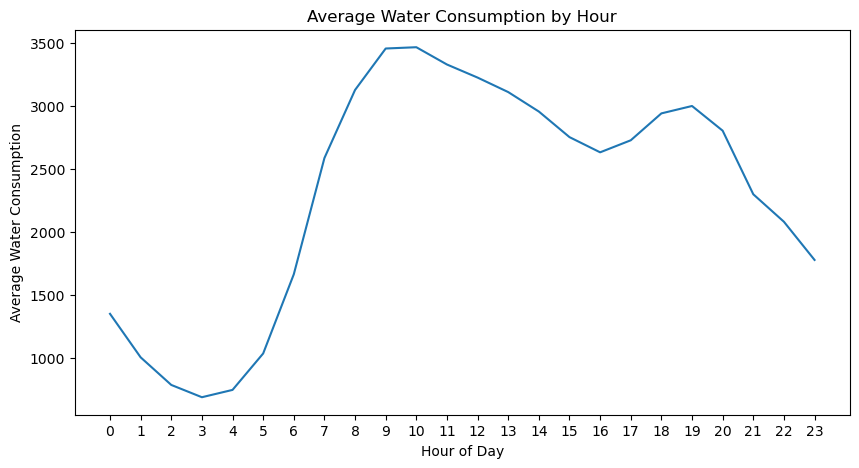

In [44]:
hourly_usage = df.groupby("Hour")["Consumption"].mean()

plt.figure(figsize=(10, 5))

plt.plot(hourly_usage.index, hourly_usage.values)

plt.xlabel("Hour of Day")
plt.ylabel("Average Water Consumption")
plt.title("Average Water Consumption by Hour")

plt.xticks(range(24))

plt.show()

In [46]:
df.to_csv(
    "../backend/datasets/water_consumption_processed.csv",
    index=False
)